# Knowledge Distillation on CIFAR-10

This notebook studies **knowledge distillation** for image classification on **CIFAR-10**. A larger **teacher** model is used to guide a smaller **student** model. The goal is to test whether the distilled student can achieve better performance than a baseline student trained with standard supervision, while keeping the same small architecture.

## What this notebook includes
- CIFAR-10 data loading and preprocessing
- A **teacher** model (ResNet-18)
- A **student** model (small CNN)
- Baseline student training with cross-entropy
- Distilled student training with teacher soft targets
- Evaluation: accuracy, parameter count, inference time
- Hyperparameter sweep for temperature and alpha
- Saved checkpoints, metrics, and plots
- A small demo with sample predictions


In [1]:
# Imports and setup
import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# Configuration
SEED = 42
DATA_ROOT = './data'
CHECKPOINT_DIR = Path('./checkpoints')
RESULTS_DIR = Path('./results')
PLOTS_DIR = RESULTS_DIR / 'plots'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

# Training toggles
TRAIN_TEACHER = False          # Set True to train/fine-tune the teacher
TRAIN_BASELINE = True        # Set True to train the baseline student
TRAIN_DISTILLED = True       # Set True to train the distilled student
RUN_SWEEP = False             # Set True to run a small hyperparameter sweep

# Data and optimization
BATCH_SIZE = 128
NUM_WORKERS = 1
VAL_RATIO = 0.1
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
TEACHER_EPOCHS = 30
TEACHER_LR = 0.03
TEACHER_WEIGHT_DECAY = 5e-4
STUDENT_EPOCHS = 10

# Distillation hyperparameters
TEMPERATURE = 4.0
ALPHA = 0.7

# Paths
TEACHER_PATH = CHECKPOINT_DIR / 'teacher_resnet18.pth'
BASELINE_PATH = CHECKPOINT_DIR / 'student_baseline.pth'
DISTILLED_PATH = CHECKPOINT_DIR / 'student_distilled.pth'
METRICS_PATH = RESULTS_DIR / 'metrics.json'
EXPERIMENTS_PATH = RESULTS_DIR / 'experiment_results.csv'


Using device: cuda


In [3]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


## Data Preparation

CIFAR-10 contains 10 classes of small natural images. We use data augmentation during training and standard normalization for all splits. A validation split is created from the training set.


In [4]:
# CIFAR-10 transforms and dataloaders
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_train_for_split = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=train_transform)
full_train_for_eval = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=eval_transform)
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=eval_transform)

val_size = int(len(full_train_for_split) * VAL_RATIO)
train_size = len(full_train_for_split) - val_size

train_dataset, val_dataset_aug = random_split(
    full_train_for_split, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
_, val_dataset = random_split(
    full_train_for_eval, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

classes = test_dataset.classes
print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))
print('Test size:', len(test_dataset))
print('Classes:', classes)


Train size: 45000
Val size: 5000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


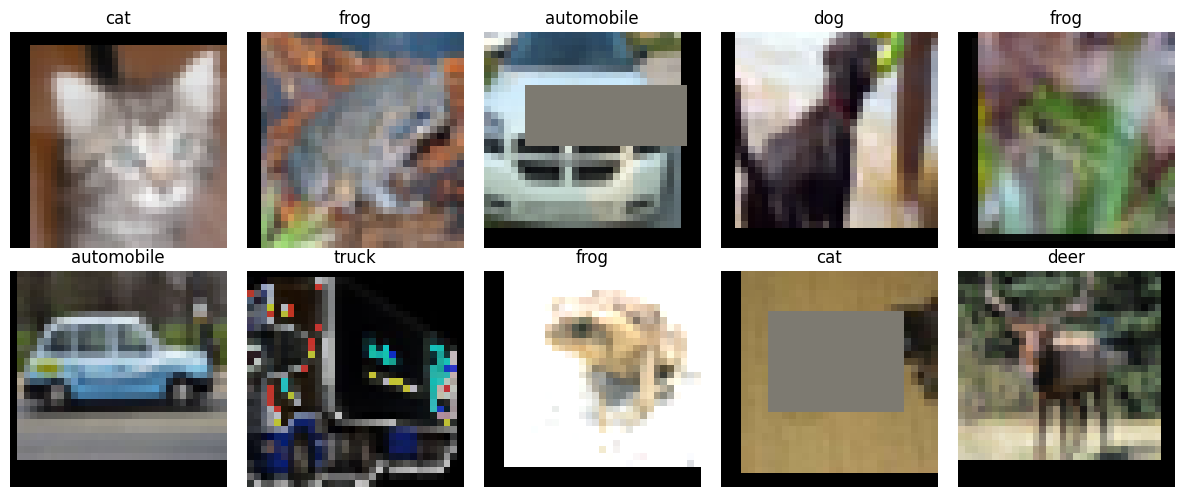

In [5]:
# Visualize a few training images

def denormalize(x, mean=MEAN, std=STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return x * std + mean

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.flat, images[:10], labels[:10]):
    ax.imshow(np.transpose(denormalize(img).clamp(0, 1).numpy(), (1, 2, 0)))
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()


## Model Definitions

The teacher is a larger **ResNet-18** model. The student is a much smaller CNN. The baseline and distilled students use the **same architecture** so any performance difference can be attributed to the training method rather than model size.


In [6]:
# Model definitions
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, base_channels=32):
        super().__init__()
        c = base_channels
        self.features = nn.Sequential(
            nn.Conv2d(3, c, kernel_size=3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),
            nn.Conv2d(c, c, kernel_size=3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(c, 2*c, kernel_size=3, padding=1),
            nn.BatchNorm2d(2*c),
            nn.ReLU(inplace=True),
            nn.Conv2d(2*c, 2*c, kernel_size=3, padding=1),
            nn.BatchNorm2d(2*c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(2*c, 4*c, kernel_size=3, padding=1),
            nn.BatchNorm2d(4*c),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(4*c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def get_teacher_model(num_classes=10):
    try:
        teacher = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        print('Loaded pretrained ResNet-18 weights.')
    except Exception as e:
        print('Could not load pretrained weights. Falling back to randomly initialized ResNet-18.')
        print('Reason:', e)
        teacher = models.resnet18(weights=None)

    # CIFAR-10 images are 32x32. The default ResNet-18 stem is too aggressive:
    # original conv1: 7x7, stride 2
    # original maxpool: further downsampling
    # This CIFAR-style stem preserves more spatial information.
    teacher.conv1 = nn.Conv2d(
        3, 64, kernel_size=3, stride=1, padding=1, bias=False
    )
    teacher.maxpool = nn.Identity()

    teacher.fc = nn.Linear(teacher.fc.in_features, num_classes)
    return teacher

def get_student_model(base_channels=32, num_classes=10):
    return SmallCNN(num_classes=num_classes, base_channels=base_channels)


In [7]:
# Utility helpers

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def save_checkpoint(path, model, extra=None):
    payload = {
        'model_state_dict': model.state_dict(),
    }
    if extra is not None:
        payload.update(extra)
    torch.save(payload, path)


def load_checkpoint(path, model, map_location=DEVICE):
    payload = torch.load(path, map_location=map_location)
    state_dict = payload['model_state_dict'] if 'model_state_dict' in payload else payload
    model.load_state_dict(state_dict)
    return payload


def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


In [8]:
# Training and evaluation loops

def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total


@torch.no_grad()
def evaluate_model(model, loader, criterion=None, device=DEVICE):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        if criterion is not None:
            running_loss += criterion(logits, labels).item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = running_loss / total if criterion is not None else None
    avg_acc = running_correct / total
    return avg_loss, avg_acc

def fit_teacher(model, train_loader, val_loader, epochs, lr=0.03, weight_decay=5e-4, device=DEVICE):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

        scheduler.step()

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {epoch+1}/{epochs} | '
            f'lr={current_lr:.5f} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    model.load_state_dict(best_state)
    return model, history, best_val_acc

def fit_supervised(model, train_loader, val_loader, epochs, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f'Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val_acc


## Knowledge Distillation Loss

The distilled student minimizes a weighted combination of:
1. **Cross-entropy loss** with the ground-truth labels
2. **Distillation loss** between the student and teacher soft predictions

A **temperature** parameter controls how soft the teacher distribution is. Higher temperatures reveal more information about relationships among classes.


In [9]:
# Knowledge distillation utilities

def distillation_loss(student_logits, teacher_logits, labels, temperature=4.0, alpha=0.7):
    ce_loss = F.cross_entropy(student_logits, labels)

    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    kd_loss = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean') * (temperature ** 2)

    total_loss = alpha * kd_loss + (1 - alpha) * ce_loss
    return total_loss, ce_loss.detach(), kd_loss.detach()


def fit_distillation(student, teacher, train_loader, val_loader, epochs, temperature=4.0, alpha=0.7,
                     lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, device=DEVICE):
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()

    optimizer = torch.optim.Adam(student.parameters(), lr=lr, weight_decay=weight_decay)
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'ce_loss': [], 'kd_loss': []
    }

    best_state = copy.deepcopy(student.state_dict())
    best_val_acc = 0.0
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        running_correct = 0
        running_ce = 0.0
        running_kd = 0.0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(images)

            student_logits = student(images)
            loss, ce, kd = distillation_loss(
                student_logits, teacher_logits, labels,
                temperature=temperature, alpha=alpha
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_ce += ce.item() * images.size(0)
            running_kd += kd.item() * images.size(0)
            running_correct += (student_logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        train_ce = running_ce / total
        train_kd = running_kd / total
        val_loss, val_acc = evaluate_model(student, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['ce_loss'].append(train_ce)
        history['kd_loss'].append(train_kd)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(student.state_dict())

        print(
            f'Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} '
            f'| ce={train_ce:.4f} kd={train_kd:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    student.load_state_dict(best_state)
    return student, history, best_val_acc


## Train or Load the Teacher

A pretrained ResNet-18 is used as the teacher. If `TRAIN_TEACHER=False`, the notebook will try to load a saved checkpoint instead. This makes the notebook easier to rerun during grading.


In [ ]:
# Teacher model
teacher = get_teacher_model(num_classes=10)
print('Teacher parameters:', f'{count_parameters(teacher):,}')

if TRAIN_TEACHER:
    teacher, teacher_history, teacher_best_val = fit_teacher(
        teacher,
        train_loader,
        val_loader,
        epochs=TEACHER_EPOCHS,
        lr=TEACHER_LR,
        weight_decay=TEACHER_WEIGHT_DECAY,
    )
    save_checkpoint(TEACHER_PATH, teacher, extra={'history': teacher_history, 'best_val_acc': teacher_best_val})
    print(f'Saved teacher checkpoint to {TEACHER_PATH}')
elif TEACHER_PATH.exists():
    teacher_payload = load_checkpoint(TEACHER_PATH, teacher)
    teacher_history = teacher_payload.get('history', None)
    print(f'Loaded teacher checkpoint from {TEACHER_PATH}')
else:
    print('No saved teacher checkpoint found. Set TRAIN_TEACHER=True to create one.')
    teacher_history = None

teacher = teacher.to(DEVICE)


Loaded pretrained ResNet-18 weights.
Teacher parameters: 11,173,962
Loaded teacher checkpoint from checkpoints/teacher_resnet18.pth


## Train or Load the Baseline Student


In [ ]:
# Baseline student
baseline_student = get_student_model(base_channels=32)
print('Baseline student parameters:', f'{count_parameters(baseline_student):,}')

if TRAIN_BASELINE:
    baseline_student, baseline_history, baseline_best_val = fit_supervised(
        baseline_student, train_loader, val_loader, epochs=STUDENT_EPOCHS
    )
    save_checkpoint(BASELINE_PATH, baseline_student, extra={'history': baseline_history, 'best_val_acc': baseline_best_val})
    print(f'Saved baseline checkpoint to {BASELINE_PATH}')
elif BASELINE_PATH.exists():
    baseline_payload = load_checkpoint(BASELINE_PATH, baseline_student)
    baseline_history = baseline_payload.get('history', None)
    print(f'Loaded baseline checkpoint from {BASELINE_PATH}')
else:
    print('No saved baseline checkpoint found. Set TRAIN_BASELINE=True to create one.')
    baseline_history = None

baseline_student = baseline_student.to(DEVICE)


Baseline student parameters: 141,354


Epoch 1/10 | train_loss=1.7393 train_acc=0.3643 | val_loss=1.3720 val_acc=0.4964
Epoch 2/10 | train_loss=1.4079 train_acc=0.4975 | val_loss=1.2192 val_acc=0.5522
Epoch 3/10 | train_loss=1.2852 train_acc=0.5465 | val_loss=1.3664 val_acc=0.5770
Epoch 4/10 | train_loss=1.1929 train_acc=0.5794 | val_loss=1.1496 val_acc=0.5862
Epoch 5/10 | train_loss=1.1261 train_acc=0.6030 | val_loss=1.2165 val_acc=0.6196
Epoch 6/10 | train_loss=1.0759 train_acc=0.6240 | val_loss=0.9040 val_acc=0.6824
Epoch 7/10 | train_loss=1.0320 train_acc=0.6378 | val_loss=1.1213 val_acc=0.6280
Epoch 8/10 | train_loss=1.0029 train_acc=0.6514 | val_loss=0.7834 val_acc=0.7278
Epoch 9/10 | train_loss=0.9679 train_acc=0.6640 | val_loss=0.9052 val_acc=0.6980
Epoch 10/10 | train_loss=0.9451 train_acc=0.6695 | val_loss=0.8522 val_acc=0.7120
Saved baseline checkpoint to checkpoints/student_baseline.pth


## Train or Load the Distilled Student


In [ ]:
# Distilled student
if not TEACHER_PATH.exists() and not TRAIN_TEACHER:
    print('Warning: teacher checkpoint is missing. Distillation requires a trained teacher.')

distilled_student = get_student_model(base_channels=32)
print('Distilled student parameters:', f'{count_parameters(distilled_student):,}')

if TRAIN_DISTILLED:
    distilled_student, distill_history, distill_best_val = fit_distillation(
        distilled_student,
        teacher,
        train_loader,
        val_loader,
        epochs=STUDENT_EPOCHS,
        temperature=TEMPERATURE,
        alpha=ALPHA,
    )
    save_checkpoint(
        DISTILLED_PATH,
        distilled_student,
        extra={
            'history': distill_history,
            'best_val_acc': distill_best_val,
            'temperature': TEMPERATURE,
            'alpha': ALPHA,
        }
    )
    print(f'Saved distilled checkpoint to {DISTILLED_PATH}')
elif DISTILLED_PATH.exists():
    distill_payload = load_checkpoint(DISTILLED_PATH, distilled_student)
    distill_history = distill_payload.get('history', None)
    print(f'Loaded distilled checkpoint from {DISTILLED_PATH}')
else:
    print('No saved distilled checkpoint found. Set TRAIN_DISTILLED=True to create one.')
    distill_history = None

distilled_student = distilled_student.to(DEVICE)


Distilled student parameters: 141,354


Epoch 1/10 | train_loss=1.4137 train_acc=0.3705 | ce=1.7736 kd=1.2595 | val_loss=1.3711 val_acc=0.5106
Epoch 2/10 | train_loss=1.1851 train_acc=0.5066 | ce=1.4708 kd=1.0626 | val_loss=1.1427 val_acc=0.6218
Epoch 3/10 | train_loss=1.0898 train_acc=0.5530 | ce=1.3510 kd=0.9778 | val_loss=1.1034 val_acc=0.6122
Epoch 4/10 | train_loss=1.0172 train_acc=0.5938 | ce=1.2592 kd=0.9134 | val_loss=1.1102 val_acc=0.6178
Epoch 5/10 | train_loss=0.9714 train_acc=0.6112 | ce=1.2049 kd=0.8714 | val_loss=0.9829 val_acc=0.6692
Epoch 6/10 | train_loss=0.9335 train_acc=0.6326 | ce=1.1544 kd=0.8388 | val_loss=0.9135 val_acc=0.6930
Epoch 7/10 | train_loss=0.9029 train_acc=0.6459 | ce=1.1189 kd=0.8103 | val_loss=0.8493 val_acc=0.7206
Epoch 8/10 | train_loss=0.8760 train_acc=0.6589 | ce=1.0860 kd=0.7860 | val_loss=0.8875 val_acc=0.7038
Epoch 9/10 | train_loss=0.8576 train_acc=0.6668 | ce=1.0643 kd=0.7690 | val_loss=0.8890 val_acc=0.7094
Epoch 10/10 | train_loss=0.8415 train_acc=0.6721 | ce=1.0474 kd=0.7532 | 

## Evaluation

We compare the teacher, the baseline student, and the distilled student on:
- test accuracy
- parameter count
- inference time per image


In [ ]:
# Evaluation helpers
@torch.no_grad()
def measure_inference_time(model, loader, device=DEVICE, num_batches=20):
    model.eval()
    total_images = 0
    start = time.perf_counter()

    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break
        images = images.to(device)
        _ = model(images)
        total_images += images.size(0)

    elapsed = time.perf_counter() - start
    return elapsed / max(total_images, 1)


def summarize_model(name, model, loader):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_model(model, loader, criterion, DEVICE)
    params = count_parameters(model)
    sec_per_image = measure_inference_time(model, loader)
    return {
        'model': name,
        'test_loss': round(float(test_loss), 4),
        'test_accuracy': round(float(test_acc), 4),
        'parameters': int(params),
        'seconds_per_image': float(sec_per_image),
    }


In [ ]:
# Final metrics table
metrics = []

if TEACHER_PATH.exists() or TRAIN_TEACHER:
    metrics.append(summarize_model('Teacher (ResNet-18)', teacher, test_loader))
if BASELINE_PATH.exists() or TRAIN_BASELINE:
    metrics.append(summarize_model('Student Baseline', baseline_student, test_loader))
if DISTILLED_PATH.exists() or TRAIN_DISTILLED:
    metrics.append(summarize_model('Student Distilled', distilled_student, test_loader))

metrics_df = pd.DataFrame(metrics)
metrics_df


,model,test_loss,test_accuracy,parameters,seconds_per_image
0,Teacher (ResNet-18),0.2196,0.9537,11173962,0.000247
1,Student Baseline,0.8087,0.7194,141354,0.000232
2,Student Distilled,0.8021,0.7441,141354,0.000233


In [ ]:
# Save summary metrics
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Saved metrics to {METRICS_PATH}')


Saved metrics to results/metrics.json


## Visualization


Saved results/plots/teacher_curves.png


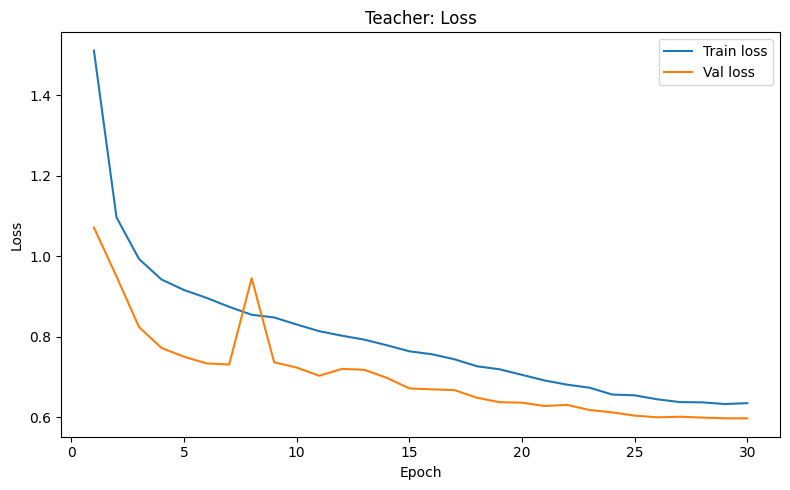

Saved results/plots/teacher_curves_acc.png


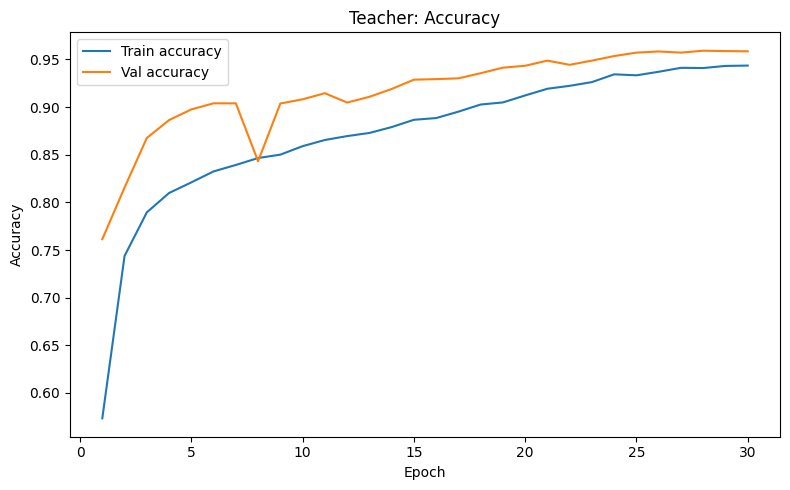

Saved results/plots/baseline_curves.png


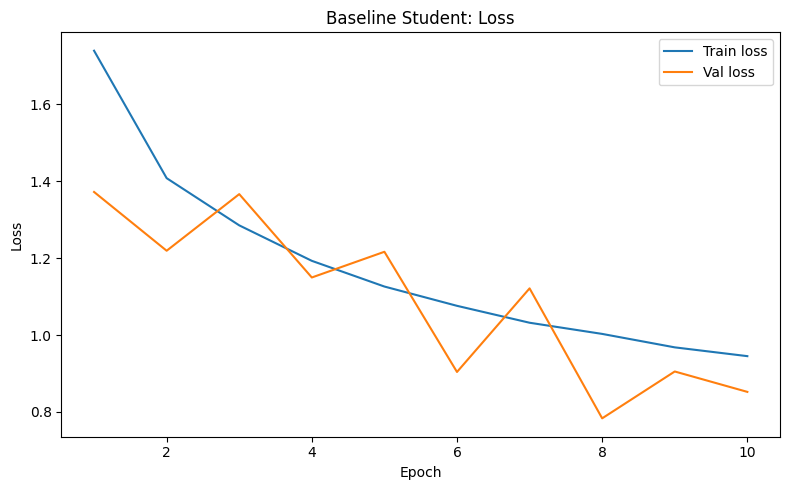

Saved results/plots/baseline_curves_acc.png


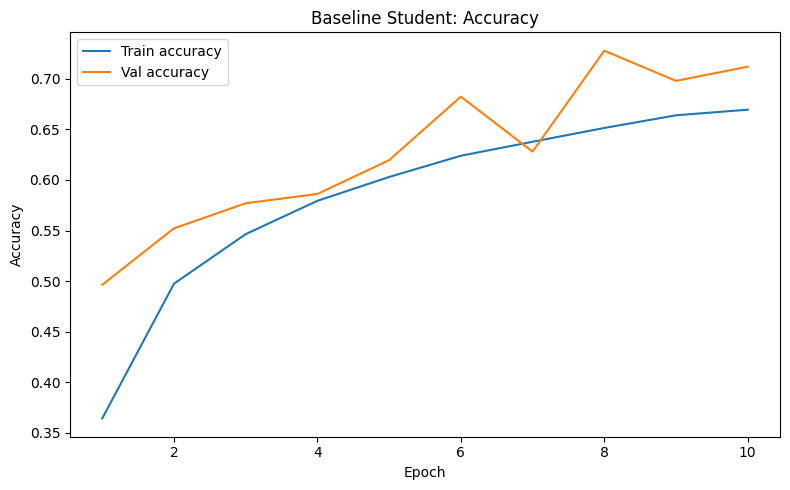

Saved results/plots/distilled_curves.png


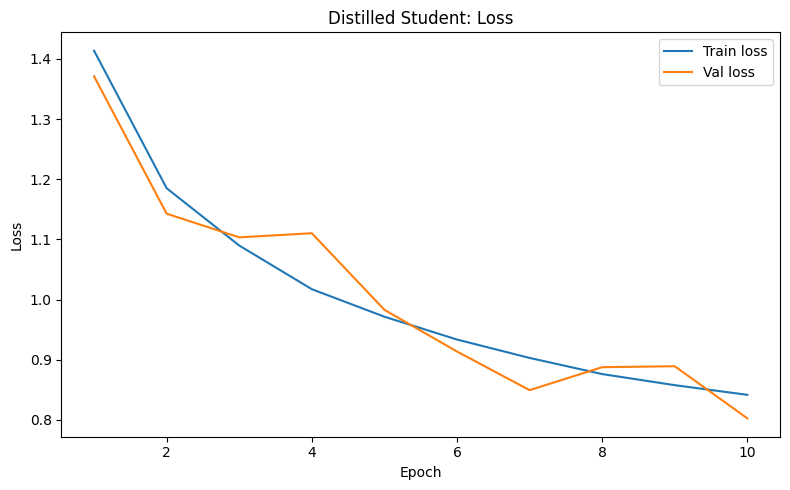

Saved results/plots/distilled_curves_acc.png


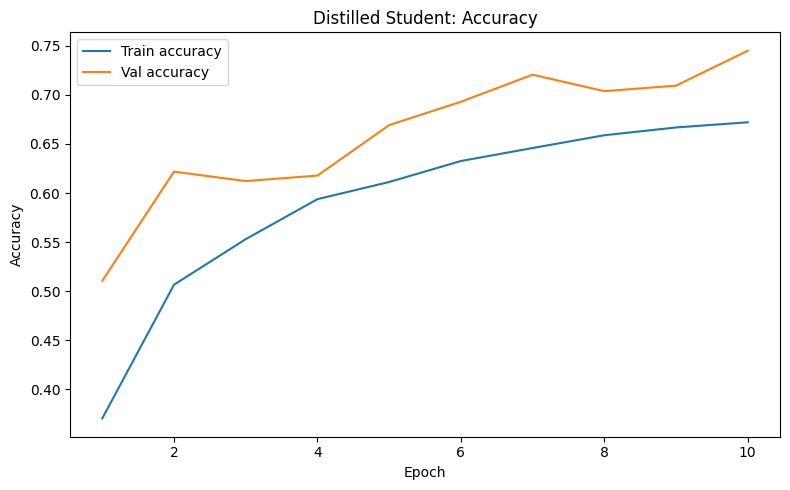

In [ ]:
# Plot training curves

def plot_history(history, title_prefix, save_name=None):
    if history is None:
        print(f'No history available for {title_prefix}.')
        return

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['val_loss'], label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}: Loss')
    plt.legend()
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name
        plt.savefig(path)
        print('Saved', path)
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='Train accuracy')
    plt.plot(epochs, history['val_acc'], label='Val accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}: Accuracy')
    plt.legend()
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name.replace('.png', '_acc.png')
        plt.savefig(path)
        print('Saved', path)
    plt.show()

plot_history(teacher_history, 'Teacher', 'teacher_curves.png')
plot_history(baseline_history, 'Baseline Student', 'baseline_curves.png')
plot_history(distill_history, 'Distilled Student', 'distilled_curves.png')


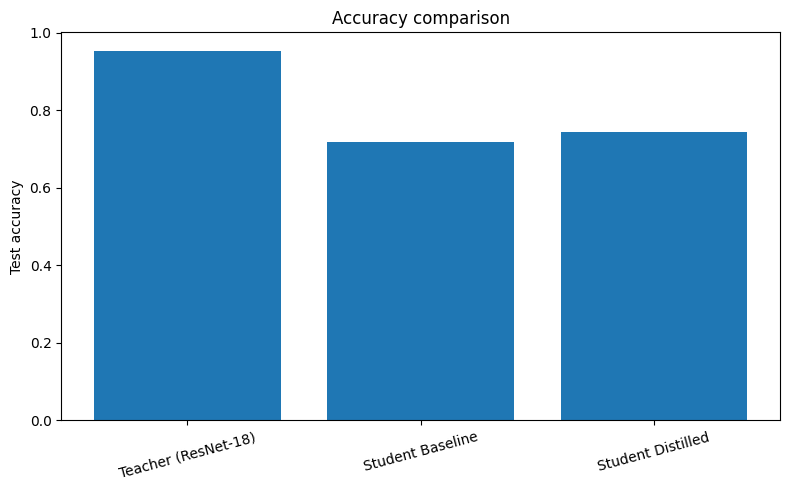

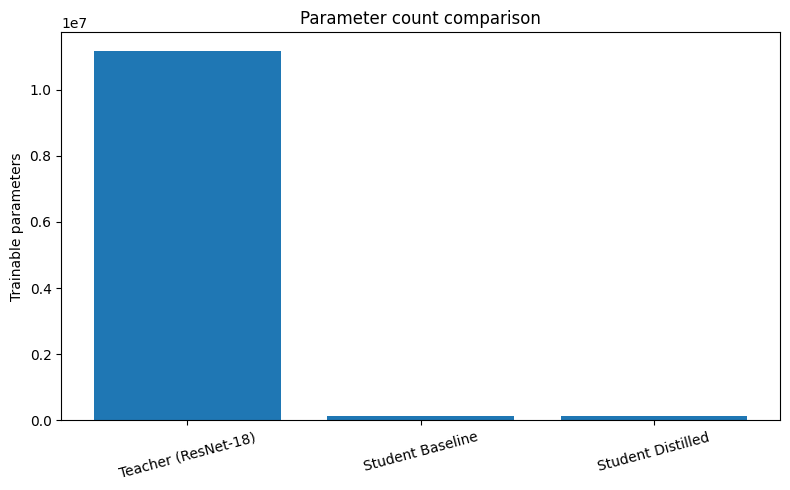

In [ ]:
# Bar charts for final comparison
if len(metrics_df) > 0:
    plt.figure()
    plt.bar(metrics_df['model'], metrics_df['test_accuracy'])
    plt.ylabel('Test accuracy')
    plt.title('Accuracy comparison')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'accuracy_comparison.png')
    plt.show()

    plt.figure()
    plt.bar(metrics_df['model'], metrics_df['parameters'])
    plt.ylabel('Trainable parameters')
    plt.title('Parameter count comparison')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'parameter_comparison.png')
    plt.show()


## Hyperparameter Sweep

This section runs a small experiment over **temperature** and **alpha** values. You can reduce the number of settings if training time is limited.


In [ ]:
# Hyperparameter sweep
sweep_results = []

if RUN_SWEEP:
    temperature_values = [2.0, 4.0, 6.0]
    alpha_values = [0.3, 0.5, 0.7]

    for temp in temperature_values:
        for alpha_value in alpha_values:
            print(f'Running sweep: temperature={temp}, alpha={alpha_value}')
            student = get_student_model(base_channels=32)
            student, hist, best_val = fit_distillation(
                student,
                teacher,
                train_loader,
                val_loader,
                epochs=max(3, STUDENT_EPOCHS // 2),
                temperature=temp,
                alpha=alpha_value,
            )
            test_loss, test_acc = evaluate_model(student, test_loader, nn.CrossEntropyLoss(), DEVICE)
            sweep_results.append({
                'temperature': temp,
                'alpha': alpha_value,
                'best_val_acc': best_val,
                'test_acc': test_acc,
            })

    sweep_df = pd.DataFrame(sweep_results)
    sweep_df.to_csv(EXPERIMENTS_PATH, index=False)
    print(f'Saved sweep results to {EXPERIMENTS_PATH}')
    display(sweep_df)
else:
    if EXPERIMENTS_PATH.exists():
        sweep_df = pd.read_csv(EXPERIMENTS_PATH)
        display(sweep_df)
    else:
        sweep_df = pd.DataFrame()
        print('No sweep results found.')


,temperature,alpha,best_val_acc,test_acc
0,2.0,0.3,0.6992,0.7076
1,2.0,0.5,0.7170,0.7146
2,2.0,0.7,0.7052,0.7021
3,4.0,0.3,0.7280,0.7334
4,4.0,0.5,0.7220,0.7218
5,4.0,0.7,0.6720,0.6642
6,6.0,0.3,0.7270,0.7282
7,6.0,0.5,0.7016,0.6992
8,6.0,0.7,0.7084,0.7057


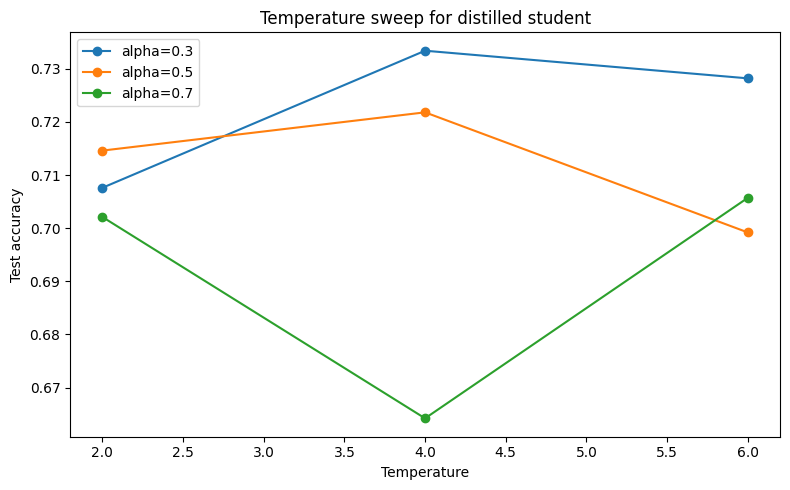

In [ ]:
# Sweep plots
if 'sweep_df' in globals() and len(sweep_df) > 0:
    for alpha_value in sorted(sweep_df['alpha'].unique()):
        subset = sweep_df[sweep_df['alpha'] == alpha_value].sort_values('temperature')
        plt.plot(subset['temperature'], subset['test_acc'], marker='o', label=f'alpha={alpha_value}')

    plt.xlabel('Temperature')
    plt.ylabel('Test accuracy')
    plt.title('Temperature sweep for distilled student')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'temperature_sweep.png')
    plt.show()


## Demo: Sample Predictions

This section shows predictions from the teacher, baseline student, and distilled student on a few test images.


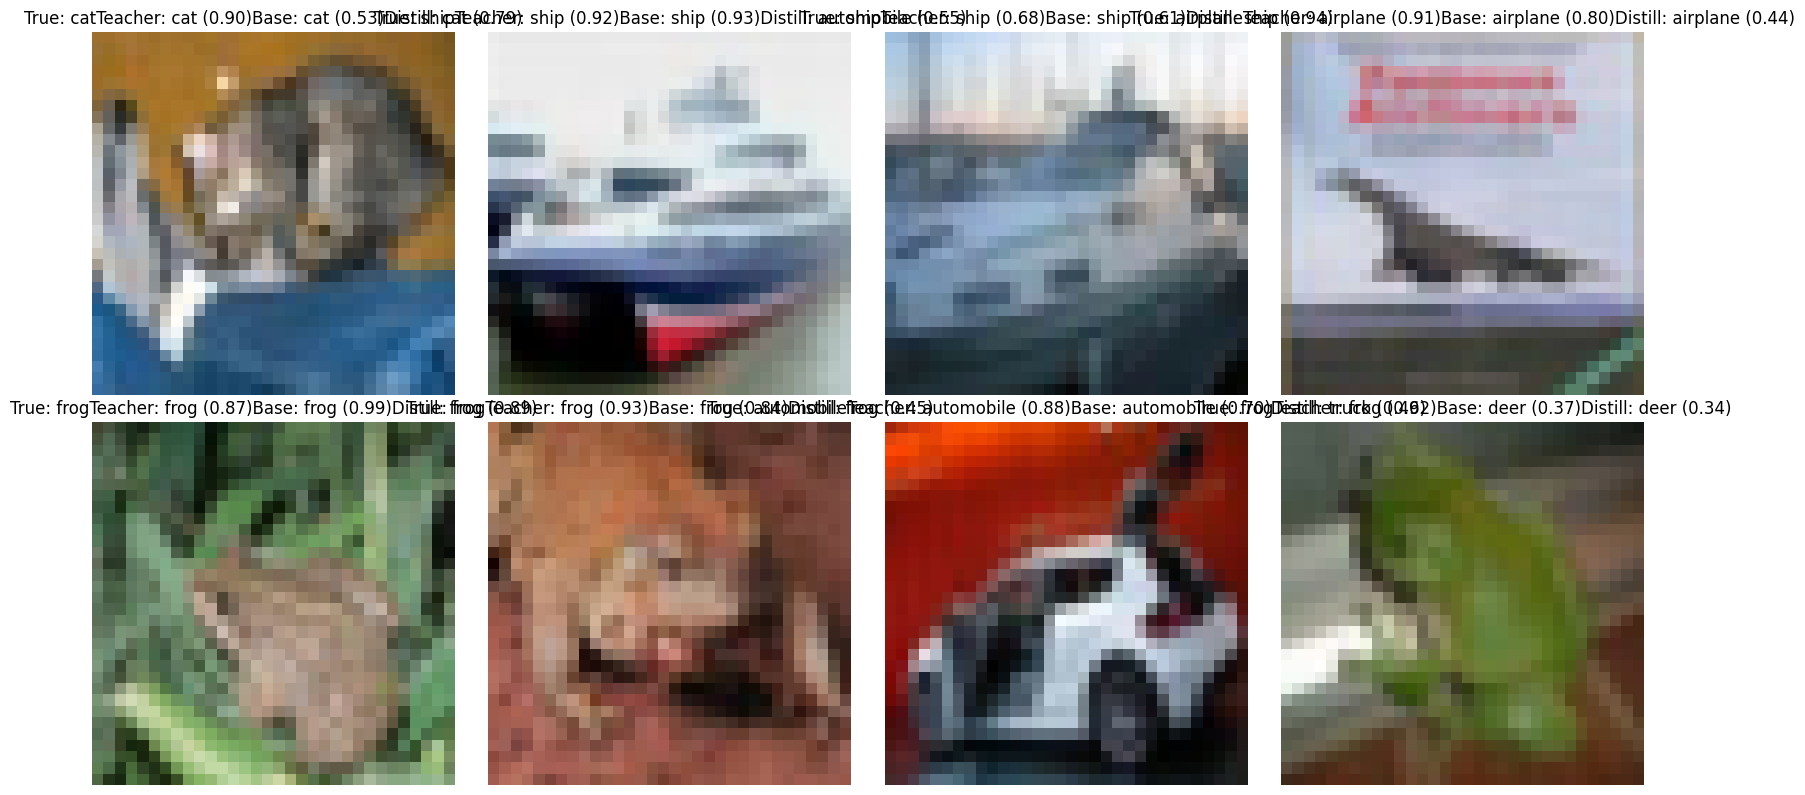

In [ ]:
# Demo predictions
@torch.no_grad()
def get_predictions(model, images, device=DEVICE):
    model.eval()
    logits = model(images.to(device))
    probs = F.softmax(logits, dim=1)
    confs, preds = probs.max(dim=1)
    return preds.cpu(), confs.cpu(), probs.cpu()

images, labels = next(iter(test_loader))
images_small = images[:8]
labels_small = labels[:8]

teacher_preds, teacher_confs, _ = get_predictions(teacher, images_small)
baseline_preds, baseline_confs, _ = get_predictions(baseline_student, images_small)
distilled_preds, distilled_confs, _ = get_predictions(distilled_student, images_small)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.transpose(denormalize(images_small[i]).clamp(0, 1).numpy(), (1, 2, 0)))
    ax.set_title(
        f'True: {classes[labels_small[i]]}'
        f'Teacher: {classes[teacher_preds[i]]} ({teacher_confs[i]:.2f})'
        f'Base: {classes[baseline_preds[i]]} ({baseline_confs[i]:.2f})'
        f'Distill: {classes[distilled_preds[i]]} ({distilled_confs[i]:.2f})'
    )
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'demo_predictions.png')
plt.show()
